In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

LASSO_DIR = Path("../outputs/lasso/lasso_candidate_features")
RIDGE_DIR = Path("../outputs/ridge_candidate_features")
ELASTICNET_DIR = Path("../outputs/elasticnet_candidate_features")

OUTPUT_DIR = Path("../outputs/regularisation_comparison")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Comparison outputs:")
print(OUTPUT_DIR.resolve())

Comparison outputs:
C:\Users\franc\OneDrive\Geop-Model\outputs\regularisation_comparison


In [10]:
# Load main saved outputs

lasso_summary = pd.read_csv(
    LASSO_DIR / "lasso_summary.csv"
)

lasso_test = pd.read_csv(
    LASSO_DIR / "lasso_test_metrics.csv",
    index_col=0
)

ridge_summary = pd.read_csv(
    RIDGE_DIR / "ridge_summary.csv"
)

ridge_test = pd.read_csv(
    RIDGE_DIR / "ridge_test_metrics.csv",
    index_col=0
)

elasticnet_summary = pd.read_csv(
    ELASTICNET_DIR / "elasticnet_summary.csv"
)

elasticnet_test = pd.read_csv(
    ELASTICNET_DIR / "elasticnet_test_metrics.csv",
    index_col=0
)

print("LASSO SUMMARY")
display(lasso_summary)

print("\nRIDGE SUMMARY")
display(ridge_summary)

print("\nELASTIC NET SUMMARY")
display(elasticnet_summary)

LASSO SUMMARY


,model,best_alpha,cv_mse,n_candidate_features,n_selected_features,test_rmse,test_mae,test_r2
0,DeepSeek_LASSO,0.000890,0.000016,124,0,0.004286,0.003365,-0.024624
1,Gemma_LASSO,0.000811,0.000016,124,0,0.004286,0.003365,-0.024624



RIDGE SUMMARY


,model,best_alpha,validation_mse,test_rmse,test_mae,test_r2,top_geopolitical_representation
0,DeepSeek_Ridge,6098.666701,0.000015,0.004474,0.003468,-0.116498,MA10
1,Gemma_Ridge,17990.099156,0.000015,0.004362,0.003408,-0.061175,MA10



ELASTIC NET SUMMARY


,model,best_alpha,best_l1_ratio,cv_mse,n_candidate_features,n_selected_features,top_geopolitical_representation
0,DeepSeek_ElasticNet,0.00085,0.99,0.000016,124,0,MA10
1,Gemma_ElasticNet,0.00085,0.95,0.000016,124,0,MA10


In [11]:
# Load representation-level diagnostic outputs

lasso_survival_deepseek = pd.read_csv(
    LASSO_DIR / "restricted_lasso_survival_ranking_deepseek.csv"
)

lasso_survival_gemma = pd.read_csv(
    LASSO_DIR / "restricted_lasso_survival_ranking_gemma.csv"
)

ridge_rep_deepseek = pd.read_csv(
    RIDGE_DIR /
    "ridge_geopolitical_representation_summary_deepseek.csv",
    index_col=0
)

ridge_rep_gemma = pd.read_csv(
    RIDGE_DIR /
    "ridge_geopolitical_representation_summary_gemma.csv",
    index_col=0
)

elasticnet_rep_deepseek = pd.read_csv(
    ELASTICNET_DIR /
    "elasticnet_representation_survival_deepseek.csv",
    index_col=0
)

elasticnet_rep_gemma = pd.read_csv(
    ELASTICNET_DIR /
    "elasticnet_representation_survival_gemma.csv",
    index_col=0
)

print("LASSO — DEEPSEEK")
display(lasso_survival_deepseek.head())

print("\nLASSO — GEMMA")
display(lasso_survival_gemma.head())

print("\nRIDGE — DEEPSEEK")
display(ridge_rep_deepseek)

print("\nELASTIC NET — DEEPSEEK")
display(elasticnet_rep_deepseek)

LASSO — DEEPSEEK


,feature,max_alpha_nonzero
0,DGS2_diff,0.000404
1,VIXCLS,0.000404
2,sanctions_sum_ma10,0.000266
3,fed_pressure_sum_ma10,0.000215
4,USEPUINDXD_diff,0.000187



LASSO — GEMMA


,feature,max_alpha_nonzero
0,DGS2_diff,0.000404
1,VIXCLS,0.000404
2,sanctions_sum_ma10,0.000351
3,fed_pressure_sum_ma10,0.000248
4,sanctions_sum,0.000201



RIDGE — DEEPSEEK


,sum,mean,count
representation,,,
MA10,0.000150,0.000017,9
Mean,0.000033,0.000011,3
Difference,0.000087,0.000010,9
MA5,0.000075,0.000008,9
Lag,0.000287,0.000008,36
MA3,0.000045,0.000005,9
Max,0.000011,0.000004,3
Sum,0.000010,0.000003,3



ELASTIC NET — DEEPSEEK


,mean,median,max,count
representation,,,,
MA10,0.000096,0.000043,0.000327,9
Difference,0.000094,0.000050,0.000327,7
Lag,0.000061,0.000031,0.000351,33
Mean,0.000046,0.000027,0.000087,3
MA5,0.000029,0.000009,0.000100,9
Sum,0.000027,0.000027,0.000028,2
Max,0.000014,0.000011,0.000031,3
MA3,0.000006,0.000005,0.000012,5


In [12]:
# CV-optimal regularisation results

cv_optimal_comparison = pd.DataFrame({
    "Method": [
        "LASSO",
        "Ridge",
        "Elastic Net"
    ],
    "DeepSeek candidate features": [
        124,
        124,
        124
    ],
    "DeepSeek selected/nonzero": [
        int(
            lasso_summary.loc[
                lasso_summary["model"] == "DeepSeek_LASSO",
                "n_selected_features"
            ].iloc[0]
        ),
        124,
        int(
            elasticnet_summary.loc[
                elasticnet_summary["model"] == "DeepSeek_ElasticNet",
                "n_selected_features"
            ].iloc[0]
        )
    ],
    "Gemma candidate features": [
        124,
        124,
        124
    ],
    "Gemma selected/nonzero": [
        int(
            lasso_summary.loc[
                lasso_summary["model"] == "Gemma_LASSO",
                "n_selected_features"
            ].iloc[0]
        ),
        124,
        int(
            elasticnet_summary.loc[
                elasticnet_summary["model"] == "Gemma_ElasticNet",
                "n_selected_features"
            ].iloc[0]
        )
    ]
})

display(cv_optimal_comparison)

,Method,DeepSeek candidate features,DeepSeek selected/nonzero,Gemma candidate features,Gemma selected/nonzero
0,LASSO,124,0,124,0
1,Ridge,124,124,124,124
2,Elastic Net,124,0,124,0


In [13]:
# OOS test performance comparison

oos_comparison = pd.DataFrame({
    "Method": [
        "LASSO",
        "LASSO",
        "Ridge",
        "Ridge",
        "Elastic Net",
        "Elastic Net"
    ],
    "LLM": [
        "DeepSeek",
        "Gemma",
        "DeepSeek",
        "Gemma",
        "DeepSeek",
        "Gemma"
    ],
    "RMSE": [
        lasso_test.loc["DeepSeek_LASSO", "RMSE"],
        lasso_test.loc["Gemma_LASSO", "RMSE"],
        ridge_test.loc["DeepSeek_Ridge", "RMSE"],
        ridge_test.loc["Gemma_Ridge", "RMSE"],
        elasticnet_test.loc["DeepSeek_ElasticNet", "RMSE"],
        elasticnet_test.loc["Gemma_ElasticNet", "RMSE"]
    ],
    "MAE": [
        lasso_test.loc["DeepSeek_LASSO", "MAE"],
        lasso_test.loc["Gemma_LASSO", "MAE"],
        ridge_test.loc["DeepSeek_Ridge", "MAE"],
        ridge_test.loc["Gemma_Ridge", "MAE"],
        elasticnet_test.loc["DeepSeek_ElasticNet", "MAE"],
        elasticnet_test.loc["Gemma_ElasticNet", "MAE"]
    ],
    "R2": [
        lasso_test.loc["DeepSeek_LASSO", "R2"],
        lasso_test.loc["Gemma_LASSO", "R2"],
        ridge_test.loc["DeepSeek_Ridge", "R2"],
        ridge_test.loc["Gemma_Ridge", "R2"],
        elasticnet_test.loc["DeepSeek_ElasticNet", "R2"],
        elasticnet_test.loc["Gemma_ElasticNet", "R2"]
    ]
})

display(oos_comparison)

,Method,LLM,RMSE,MAE,R2
0,LASSO,DeepSeek,0.004286,0.003365,-0.024624
1,LASSO,Gemma,0.004286,0.003365,-0.024624
2,Ridge,DeepSeek,0.004474,0.003468,-0.116498
3,Ridge,Gemma,0.004362,0.003408,-0.061175
4,Elastic Net,DeepSeek,0.004286,0.003365,-0.024624
5,Elastic Net,Gemma,0.004286,0.003365,-0.024624


In [14]:
# Naive benchmark performance

benchmark_comparison = pd.DataFrame({
    "Benchmark": [
        "Mean",
        "Zero"
    ],
    "RMSE": [
        elasticnet_test.loc["Mean_Benchmark", "RMSE"],
        elasticnet_test.loc["Zero_Benchmark", "RMSE"]
    ],
    "MAE": [
        elasticnet_test.loc["Mean_Benchmark", "MAE"],
        elasticnet_test.loc["Zero_Benchmark", "MAE"]
    ],
    "R2": [
        elasticnet_test.loc["Mean_Benchmark", "R2"],
        elasticnet_test.loc["Zero_Benchmark", "R2"]
    ]
})

display(benchmark_comparison)

,Benchmark,RMSE,MAE,R2
0,Mean,0.004286,0.003365,-0.024624
1,Zero,0.004287,0.003366,-0.024999


In [16]:
# Representation-level evidence

representation_evidence = pd.DataFrame({
    "Method": [
        "LASSO",
        "Ridge",
        "Elastic Net"
    ],
    "Evidence basis": [
        "Restricted 18-feature coefficient-path persistence",
        "Full 124-feature mean absolute standardized coefficients",
        "Full 124-feature coefficient-path survival"
    ],
    "DeepSeek result": [
        "MA10 Sanctions and Fed Pressure among most persistent",
        ridge_rep_deepseek["mean"].idxmax(),
        elasticnet_rep_deepseek["mean"].idxmax()
    ],
    "Gemma result": [
        "MA10 Sanctions and Fed Pressure among most persistent",
        ridge_rep_gemma["mean"].idxmax(),
        elasticnet_rep_gemma["mean"].idxmax()
    ]
})

display(representation_evidence)

,Method,Evidence basis,DeepSeek result,Gemma result
0,LASSO,Restricted 18-feature coefficient-path persist...,MA10 Sanctions and Fed Pressure among most per...,MA10 Sanctions and Fed Pressure among most per...
1,Ridge,Full 124-feature mean absolute standardized co...,MA10,MA10
2,Elastic Net,Full 124-feature coefficient-path survival,MA10,MA10


In [17]:
# Final regularisation performance table

final_performance = pd.concat([
    oos_comparison,
    pd.DataFrame({
        "Method": [
            "Mean Benchmark",
            "Zero Benchmark"
        ],
        "LLM": [
            "—",
            "—"
        ],
        "RMSE": [
            benchmark_comparison.loc[
                benchmark_comparison["Benchmark"] == "Mean",
                "RMSE"
            ].iloc[0],
            benchmark_comparison.loc[
                benchmark_comparison["Benchmark"] == "Zero",
                "RMSE"
            ].iloc[0]
        ],
        "MAE": [
            benchmark_comparison.loc[
                benchmark_comparison["Benchmark"] == "Mean",
                "MAE"
            ].iloc[0],
            benchmark_comparison.loc[
                benchmark_comparison["Benchmark"] == "Zero",
                "MAE"
            ].iloc[0]
        ],
        "R2": [
            benchmark_comparison.loc[
                benchmark_comparison["Benchmark"] == "Mean",
                "R2"
            ].iloc[0],
            benchmark_comparison.loc[
                benchmark_comparison["Benchmark"] == "Zero",
                "R2"
            ].iloc[0]
        ]
    })
], ignore_index=True)

display(final_performance)

,Method,LLM,RMSE,MAE,R2
0,LASSO,DeepSeek,0.004286,0.003365,-0.024624
1,LASSO,Gemma,0.004286,0.003365,-0.024624
2,Ridge,DeepSeek,0.004474,0.003468,-0.116498
3,Ridge,Gemma,0.004362,0.003408,-0.061175
4,Elastic Net,DeepSeek,0.004286,0.003365,-0.024624
5,Elastic Net,Gemma,0.004286,0.003365,-0.024624
6,Mean Benchmark,—,0.004286,0.003365,-0.024624
7,Zero Benchmark,—,0.004287,0.003366,-0.024999


In [18]:
# Final cross-method synthesis

final_synthesis = pd.DataFrame({
    "Method": [
        "LASSO",
        "Ridge",
        "Elastic Net"
    ],
    "CV-optimal result": [
        "0 / 124 non-zero predictors",
        "124 / 124 retained and shrunk",
        "0 / 124 non-zero predictors"
    ],
    "OOS result": [
        "Matches mean benchmark",
        "Underperforms naive benchmarks",
        "Matches mean benchmark"
    ],
    "Geopolitical representation evidence": [
        "Restricted paths: MA10 Sanctions and Fed Pressure among most persistent",
        "Full candidate set: MA10 highest mean absolute coefficient",
        "Full candidate set: MA10 highest mean survival"
    ],
    "LLM consistency": [
        "Similar result for DeepSeek and Gemma",
        "MA10 top representation for both",
        "MA10 top representation for both"
    ]
})

display(final_synthesis)

,Method,CV-optimal result,OOS result,Geopolitical representation evidence,LLM consistency
0,LASSO,0 / 124 non-zero predictors,Matches mean benchmark,Restricted paths: MA10 Sanctions and Fed Press...,Similar result for DeepSeek and Gemma
1,Ridge,124 / 124 retained and shrunk,Underperforms naive benchmarks,Full candidate set: MA10 highest mean absolute...,MA10 top representation for both
2,Elastic Net,0 / 124 non-zero predictors,Matches mean benchmark,Full candidate set: MA10 highest mean survival,MA10 top representation for both


In [19]:
# Save final comparison outputs

cv_optimal_comparison.to_csv(
    OUTPUT_DIR / "cv_optimal_selection_comparison.csv",
    index=False
)

oos_comparison.to_csv(
    OUTPUT_DIR / "regularisation_oos_comparison.csv",
    index=False
)

benchmark_comparison.to_csv(
    OUTPUT_DIR / "naive_benchmark_comparison.csv",
    index=False
)

representation_evidence.to_csv(
    OUTPUT_DIR / "representation_evidence_comparison.csv",
    index=False
)

final_performance.to_csv(
    OUTPUT_DIR / "final_regularisation_performance.csv",
    index=False
)

final_synthesis.to_csv(
    OUTPUT_DIR / "final_regularisation_synthesis.csv",
    index=False
)

print("All regularisation comparison outputs saved to:")
print(OUTPUT_DIR.resolve())

All regularisation comparison outputs saved to:
C:\Users\franc\OneDrive\Geop-Model\outputs\regularisation_comparison


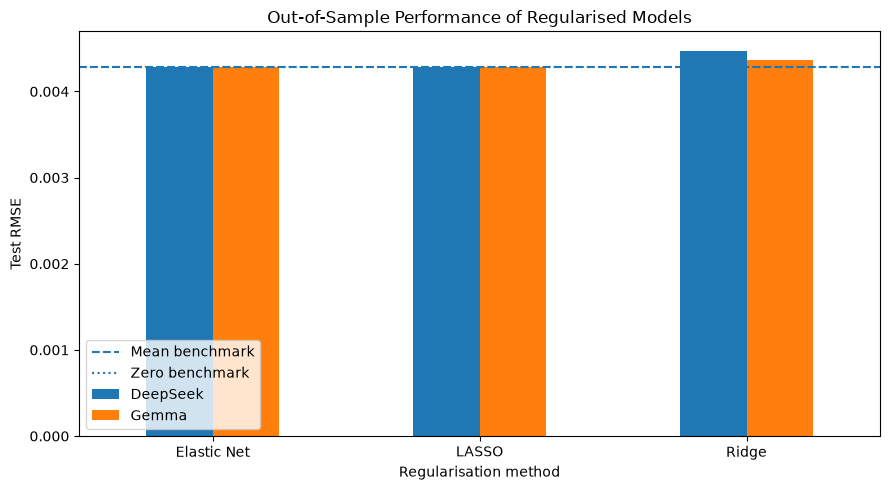

In [20]:
# OOS RMSE comparison across regularisation methods

rmse_plot = (
    oos_comparison
    .pivot(
        index="Method",
        columns="LLM",
        values="RMSE"
    )
)

ax = rmse_plot.plot(
    kind="bar",
    figsize=(9, 5)
)

mean_rmse = benchmark_comparison.loc[
    benchmark_comparison["Benchmark"] == "Mean",
    "RMSE"
].iloc[0]

zero_rmse = benchmark_comparison.loc[
    benchmark_comparison["Benchmark"] == "Zero",
    "RMSE"
].iloc[0]

ax.axhline(
    mean_rmse,
    linestyle="--",
    label="Mean benchmark"
)

ax.axhline(
    zero_rmse,
    linestyle=":",
    label="Zero benchmark"
)

ax.set_title(
    "Out-of-Sample Performance of Regularised Models"
)

ax.set_xlabel("Regularisation method")
ax.set_ylabel("Test RMSE")

plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "regularisation_oos_rmse_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [21]:
# Final consistency checks

print("=" * 65)
print("REGULARISATION COMPARISON — FINAL CHECK")
print("=" * 65)

print("\nCV-OPTIMAL FEATURE RETENTION")
display(cv_optimal_comparison)

print("\nOOS PERFORMANCE")
display(final_performance)

print("\nREPRESENTATION EVIDENCE")
display(representation_evidence)

print("\nKEY CHECKS")

print(
    "Ridge top representation — DeepSeek:",
    ridge_rep_deepseek["mean"].idxmax()
)

print(
    "Ridge top representation — Gemma:",
    ridge_rep_gemma["mean"].idxmax()
)

print(
    "Elastic Net top representation — DeepSeek:",
    elasticnet_rep_deepseek["mean"].idxmax()
)

print(
    "Elastic Net top representation — Gemma:",
    elasticnet_rep_gemma["mean"].idxmax()
)

print(
    "\nLASSO selected predictors:",
    cv_optimal_comparison.loc[
        cv_optimal_comparison["Method"] == "LASSO",
        [
            "DeepSeek selected/nonzero",
            "Gemma selected/nonzero"
        ]
    ].values[0]
)

print(
    "Elastic Net selected predictors:",
    cv_optimal_comparison.loc[
        cv_optimal_comparison["Method"] == "Elastic Net",
        [
            "DeepSeek selected/nonzero",
            "Gemma selected/nonzero"
        ]
    ].values[0]
)

print("\nComparison outputs:")
print(OUTPUT_DIR.resolve())

REGULARISATION COMPARISON — FINAL CHECK

CV-OPTIMAL FEATURE RETENTION


,Method,DeepSeek candidate features,DeepSeek selected/nonzero,Gemma candidate features,Gemma selected/nonzero
0,LASSO,124,0,124,0
1,Ridge,124,124,124,124
2,Elastic Net,124,0,124,0



OOS PERFORMANCE


,Method,LLM,RMSE,MAE,R2
0,LASSO,DeepSeek,0.004286,0.003365,-0.024624
1,LASSO,Gemma,0.004286,0.003365,-0.024624
2,Ridge,DeepSeek,0.004474,0.003468,-0.116498
3,Ridge,Gemma,0.004362,0.003408,-0.061175
4,Elastic Net,DeepSeek,0.004286,0.003365,-0.024624
5,Elastic Net,Gemma,0.004286,0.003365,-0.024624
6,Mean Benchmark,—,0.004286,0.003365,-0.024624
7,Zero Benchmark,—,0.004287,0.003366,-0.024999



REPRESENTATION EVIDENCE


,Method,Evidence basis,DeepSeek result,Gemma result
0,LASSO,Restricted 18-feature coefficient-path persist...,MA10 Sanctions and Fed Pressure among most per...,MA10 Sanctions and Fed Pressure among most per...
1,Ridge,Full 124-feature mean absolute standardized co...,MA10,MA10
2,Elastic Net,Full 124-feature coefficient-path survival,MA10,MA10



KEY CHECKS
Ridge top representation — DeepSeek: MA10
Ridge top representation — Gemma: MA10
Elastic Net top representation — DeepSeek: MA10
Elastic Net top representation — Gemma: MA10

LASSO selected predictors: [0 0]
Elastic Net selected predictors: [0 0]

Comparison outputs:
C:\Users\franc\OneDrive\Geop-Model\outputs\regularisation_comparison


## Regularisation comparison — conclusion

The three regularisation methods provide two distinct findings.

**Predictive performance.** At their cross-validation-selected penalties, LASSO and Elastic Net shrink all 124 candidate coefficients to zero for both DeepSeek and Gemma and therefore reproduce the historical-mean benchmark on the held-out test sample. Ridge retains all predictors under shrinkage, but its out-of-sample performance is worse than the naïve mean and zero-return benchmarks. Thus, the expanded predictor set does not provide evidence of improved one-step-ahead EUR/USD return forecasting under these regularised specifications.

**Geopolitical representation.** The secondary regularisation diagnostics nevertheless provide evidence on the relative representation of the geopolitical indices. In the restricted LASSO coefficient paths, MA10 Sanctions and Fed Pressure variables are among the most persistent geopolitical predictors. In the full candidate-feature analyses, MA10 is the highest-ranked geopolitical representation for both DeepSeek and Gemma under both Ridge and Elastic Net diagnostics.

Taken together, these results support retaining the MA10 aggregation as the benchmark geopolitical representation for the VARX analysis, while not implying that the regularised models themselves demonstrate out-of-sample predictive gains.